In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u

from scipy.interpolate import splev, splrep, interp1d
import scipy.optimize as opt
from scipy.signal import find_peaks, medfilt

# Gaussian process for curve fitting
#import george
#from george.kernels import ExpSquaredKernel

import glob

from pdastro import *
from LC_utility import *

In [2]:
from regions import Regions

regions = Regions.read("ec0915_good2pos.reg", format="ds9")

ra = [reg.center.ra.deg for reg in regions]

dec = [reg.center.dec.deg for reg in regions]

In [3]:
bad_expnums_a54i = pd.read_csv('txt_files/a54i_badims.csv')['a54'].values
bad_expnums_a57i = pd.read_csv('txt_files/a57i_badims.csv')['a57'].values


In [7]:
url_54_i = "https://stsci-transients.stsci.edu/\
eta/etalc/results/rod_test/good2_i/\
ec0915/54/ec0915a54_good2pos_i_tmpl523435.html"
table_a54_i = get_LCtable(url_54_i)

url_57_i = "https://stsci-transients.stsci.edu/\
eta/etalc/results/rod_test/good2_i/\
ec0915/57/ec0915a57_good2pos_i_tmpl523435.html"
table_a57_i = get_LCtable(url_57_i)




In [8]:
table_a57_i.to_csv('good2/LCref_a57_i.csv', index=False)


lc_list1_i = get_LCdata(table_a57_i, group=0, )


lc_list1_i.to_csv('good2/LCtable1_i.csv', index=False)


In [9]:
lc_df1 = readin_LCdf('good2/LCtable1_i.csv')


In [11]:
lc_df1.t

,ID,x,y,bsize,mjd,zpt,fluxADU,flux_err,X2norm,Npix,...,CONVOL00,PHOTNORM,KSUM00,FSIG00,FSCAT00,FWHM,M5SIGMA,SKYADU,muJyas2,muJyas2_err
0,0,2069,2290,3,56341.211110,30.151,2.61,5.02,1.04,9,...,TEMPLATE,t,1.0856,1.384,0.109,3.834,23.216,1025.0,0.11320,0.2175
1,0,2069,2290,3,56341.216066,30.151,6.83,4.74,0.42,9,...,TEMPLATE,t,1.0883,1.335,0.080,4.222,23.151,1006.0,0.29610,0.2053
2,0,2069,2290,3,56341.219000,30.151,-3.06,4.87,1.15,9,...,TEMPLATE,t,1.1000,1.419,0.123,3.981,23.186,1023.0,-0.13280,0.2110
3,0,2069,2290,3,56343.220957,30.151,-1.11,5.62,0.23,9,...,TEMPLATE,t,1.1045,1.460,0.141,4.085,23.090,1220.0,-0.04828,0.2435
4,0,2069,2290,3,56343.222439,30.151,5.51,5.28,1.20,9,...,TEMPLATE,t,1.1069,1.426,0.125,4.061,23.070,1233.0,0.23900,0.2290
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6145,14,2059,2285,3,61136.291582,30.151,68.77,8.91,2.22,9,...,TEMPLATE,t,1.0120,1.079,0.051,5.276,22.231,2618.0,2.98100,0.3865
6146,14,2059,2285,3,61137.222243,30.151,67.91,7.30,0.45,9,...,TEMPLATE,t,1.0208,1.117,0.091,3.594,22.773,2029.0,2.94400,0.3165
6147,14,2059,2285,3,61138.026535,30.151,70.66,7.08,1.13,9,...,TEMPLATE,t,1.0286,1.095,0.067,4.956,22.506,1581.0,3.06300,0.3071
6148,14,2059,2285,3,61139.226119,30.151,63.97,7.09,0.87,9,...,TEMPLATE,t,1.0154,1.204,0.136,3.126,23.071,1400.0,2.77300,0.3074


<ErrorbarContainer object of 3 artists>

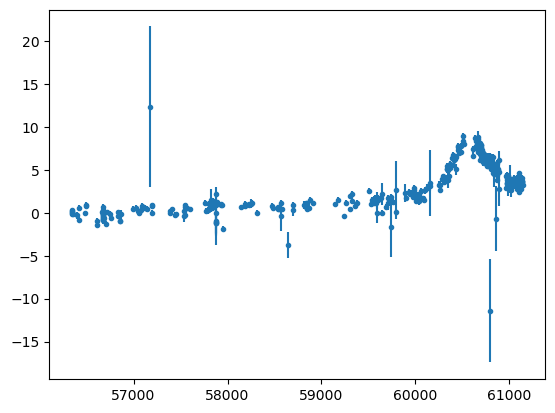

In [13]:
i = 0
x = lc_list1_i[lc_list1_i['ID']==i].mjd
y = lc_list1_i[lc_list1_i['ID']==i].muJyas2
yerr = lc_list1_i[lc_list1_i['ID']==i].muJyas2_err

plt.errorbar(x,  y,  yerr, fmt='.')

#plt.xlim([60790, 60800])